# Hito 3 — Refinamiento, Modelado Avanzado e Integración
## CRISP-DM Fases 4 (Avanzada) y 5 | ALDIMI Predict

| Frente | Modelos Avanzados | Técnica Balanceo | Dataset |
|---|---|---|---|
| Clasificación de Riesgo de Salud | Random Forest · XGBoost | SMOTE | `cancer-risk-factors.csv` |
| Predicción de Stock Logístico | Random Forest · XGBoost | — (regresión) | `inventory_data.csv` |

**Baseline Hito 2:** Árbol de Decisión (F1-macro ≈ 0.57) · Regresión Lineal (R² ≈ 0.82 / 0.64)

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, cross_val_score, learning_curve, TimeSeriesSplit
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score,
    mean_absolute_error, mean_squared_error, r2_score
)

try:
    from xgboost import XGBClassifier, XGBRegressor
    HAS_XGB = True
    print("XGBoost disponible.")
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier as XGBClassifier
    from sklearn.ensemble import GradientBoostingRegressor as XGBRegressor
    HAS_XGB = False
    print("XGBoost no instalado — usando GradientBoosting de sklearn (pip install xgboost para XGBoost real).")

try:
    from imblearn.over_sampling import SMOTE
    HAS_SMOTE = True
    print("imbalanced-learn disponible.")
except ImportError:
    HAS_SMOTE = False
    print("imbalanced-learn no instalado — usando class_weight='balanced' (pip install imbalanced-learn para SMOTE).")

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

XGBoost disponible.
imbalanced-learn disponible.


## Reproducción del Preprocessing (Hito 2)

Se replican la ingeniería de características y splits del Hito 2 para garantizar comparabilidad exacta con el baseline.

In [18]:
df_cancer = pd.read_csv('../datos/cancer-risk-factors.csv')
df_inv    = pd.read_csv('../datos/inventory_data.csv')

# ── Frente de Salud ──────────────────────────────────────────────────────────
df_cancer['Risk_Lifestyle'] = (df_cancer['Smoking']
                               + df_cancer['Alcohol_Use']
                               + df_cancer['Air_Pollution'])
df_cancer['Diet_Score']     = (df_cancer['Diet_Salted_Processed']
                               + df_cancer['Diet_Red_Meat']
                               - df_cancer['Fruit_Veg_Intake'])
df_cancer['Genetic_Risk']   = (df_cancer['BRCA_Mutation']
                               + df_cancer['Family_History']
                               + df_cancer['H_Pylori_Infection'])

le_cancer_type = LabelEncoder()
df_cancer['Cancer_Type_enc'] = le_cancer_type.fit_transform(df_cancer['Cancer_Type'])

FEATURE_COLS_CANCER = [
    'Age', 'Gender', 'Smoking', 'Alcohol_Use', 'Obesity', 'Family_History',
    'Diet_Red_Meat', 'Diet_Salted_Processed', 'Fruit_Veg_Intake',
    'Physical_Activity', 'Air_Pollution', 'Occupational_Hazards',
    'BRCA_Mutation', 'H_Pylori_Infection', 'Calcium_Intake',
    'BMI', 'Physical_Activity_Level', 'Cancer_Type_enc',
    'Risk_Lifestyle', 'Diet_Score', 'Genetic_Risk'
    # Overall_Risk_Score y Metastasis_Status excluidas — data leakage (Hito 2)
]

le_target = LabelEncoder()
y_cancer  = le_target.fit_transform(df_cancer['Risk_Level'])
X_cancer  = df_cancer[FEATURE_COLS_CANCER]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer
)

# ── Frente Logístico ─────────────────────────────────────────────────────────
df_inv['Date']        = pd.to_datetime(df_inv['Date'])
df_inv['Month']       = df_inv['Date'].dt.month
df_inv['Quarter']     = df_inv['Date'].dt.quarter
df_inv['Day_of_Week'] = df_inv['Date'].dt.dayofweek

df_inv['Projected_Stock_7d']  = (df_inv['Current_Stock']
                                  - df_inv['Avg_Usage_Per_Day'] * 7).clip(lower=0)
df_inv['Projected_Stock_14d'] = (df_inv['Current_Stock']
                                  - df_inv['Avg_Usage_Per_Day'] * 14).clip(lower=0)
df_inv['Days_Until_Stockout'] = (df_inv['Current_Stock']
                                  / df_inv['Avg_Usage_Per_Day']).round(2)
df_inv['Stock_Ratio']         = (df_inv['Current_Stock']
                                  / df_inv['Min_Required']).round(3)

le_item = LabelEncoder()
le_type = LabelEncoder()
df_inv['Item_Name_enc'] = le_item.fit_transform(df_inv['Item_Name'])
df_inv['Item_Type_enc'] = le_type.fit_transform(df_inv['Item_Type'])

# ── Features de lag temporal (novedad Hito 3) ────────────────────────────────
df_inv_ts = df_inv.sort_values(['Item_Name', 'Date']).copy()
df_inv_ts['Stock_Lag1'] = df_inv_ts.groupby('Item_Name')['Current_Stock'].shift(1)
df_inv_ts['Stock_Lag7'] = df_inv_ts.groupby('Item_Name')['Current_Stock'].shift(7)
df_inv_ts['Stock_RollingMean7'] = (
    df_inv_ts.groupby('Item_Name')['Current_Stock']
    .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
)
df_inv_ts = df_inv_ts.dropna(subset=['Stock_Lag1']).reset_index(drop=True)

FEATURE_COLS_INV = [
    'Current_Stock', 'Min_Required', 'Max_Capacity', 'Unit_Cost',
    'Avg_Usage_Per_Day', 'Restock_Lead_Time',
    'Item_Name_enc', 'Item_Type_enc',
    'Month', 'Quarter', 'Day_of_Week',
    'Stock_Ratio', 'Days_Until_Stockout'
]

FEATURE_COLS_INV_TS = FEATURE_COLS_INV + ['Stock_Lag1', 'Stock_Lag7', 'Stock_RollingMean7']

X_inv    = df_inv[FEATURE_COLS_INV]
y_inv_7  = df_inv['Projected_Stock_7d']
y_inv_14 = df_inv['Projected_Stock_14d']

idx = np.arange(len(X_inv))
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=42)
X_train_i  = X_inv.iloc[train_idx];   X_test_i  = X_inv.iloc[test_idx]
y_train_7  = y_inv_7.iloc[train_idx]; y_test_7  = y_inv_7.iloc[test_idx]
y_train_14 = y_inv_14.iloc[train_idx];y_test_14 = y_inv_14.iloc[test_idx]

# ── Baseline Hito 2 (referencia) ─────────────────────────────────────────────
dt_base = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt_base.fit(X_train_c, y_train_c)
baseline_f1    = f1_score(y_test_c, dt_base.predict(X_test_c), average='macro')

lr_7  = LinearRegression().fit(X_train_i, y_train_7)
lr_14 = LinearRegression().fit(X_train_i, y_train_14)
baseline_mae_7  = mean_absolute_error(y_test_7,  lr_7.predict(X_test_i))
baseline_mae_14 = mean_absolute_error(y_test_14, lr_14.predict(X_test_i))
baseline_r2_7   = r2_score(y_test_7,  lr_7.predict(X_test_i))
baseline_r2_14  = r2_score(y_test_14, lr_14.predict(X_test_i))

print(f"Datasets cargados: Salud {df_cancer.shape} · Inventario {df_inv.shape}")
print(f"Baseline Hito 2  — F1-macro: {baseline_f1:.4f}")
print(f"                 — MAE 7d: {baseline_mae_7:.1f}  R²: {baseline_r2_7:.4f}")
print(f"                 — MAE 14d: {baseline_mae_14:.1f}  R²: {baseline_r2_14:.4f}")

Datasets cargados: Salud (2000, 26) · Inventario (500, 20)
Baseline Hito 2  — F1-macro: 0.5485
                 — MAE 7d: 364.0  R²: 0.8219
                 — MAE 14d: 386.6  R²: 0.6389


---
## Fase 4 (Avanzada) — Frente de Salud: Clasificación de Riesgo

### 4.1 SMOTE — Sobremuestreo de Clases Minoritarias

El dataset presenta un desbalanceo severo (High: 5.1%). SMOTE genera ejemplos sintéticos
interpolando entre vecinos reales **solo en entrenamiento**, nunca en test.

> **Nota metodológica:** para producción se implementaría dentro de un `Pipeline` de
> imbalanced-learn para evitar fuga de información en CV. En este ejercicio académico
> se aplica sobre el fold de entrenamiento completo antes del ajuste de hiperparámetros.

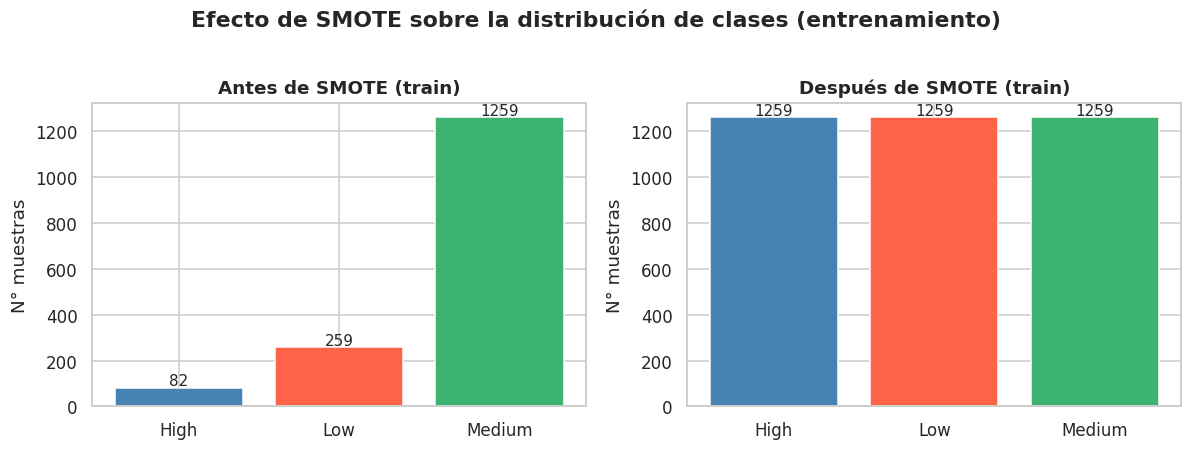

Train original: 1600 muestras → Con SMOTE: 3777 muestras
  High: 82 → 1259
  Low: 259 → 1259
  Medium: 1259 → 1259


In [19]:
if HAS_SMOTE:
    smote = SMOTE(random_state=42, k_neighbors=3)
    X_train_sm, y_train_sm = smote.fit_resample(X_train_c, y_train_c)
else:
    X_train_sm, y_train_sm = X_train_c.copy(), y_train_c.copy()

dist_before = pd.Series(y_train_c).value_counts().sort_index()
dist_after  = pd.Series(y_train_sm).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, dist, title in zip(axes,
                            [dist_before, dist_after],
                            ['Antes de SMOTE (train)', 'Después de SMOTE (train)']):
    bars = ax.bar([le_target.classes_[i] for i in dist.index], dist.values,
                  color=['steelblue', 'tomato', 'mediumseagreen'], edgecolor='white')
    for bar, v in zip(bars, dist.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(v), ha='center', fontsize=10)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('N° muestras')

plt.suptitle('Efecto de SMOTE sobre la distribución de clases (entrenamiento)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

if HAS_SMOTE:
    print(f"Train original: {len(y_train_c)} muestras → Con SMOTE: {len(y_train_sm)} muestras")
    for i, cls in enumerate(le_target.classes_):
        print(f"  {cls}: {dist_before.get(i,0)} → {dist_after.get(i,0)}")
else:
    print("Sin SMOTE — se usará class_weight='balanced' en los modelos.")

### 4.2 Random Forest + GridSearchCV

In [20]:
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_rf = {
    'n_estimators':    [100, 200],
    'max_depth':       [5, 10, None],
    'min_samples_split': [2, 5],
    'class_weight':    ['balanced'],
}

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf, cv=cv_strat,
    scoring='f1_macro', n_jobs=-1, verbose=0
)
gs_rf.fit(X_train_sm, y_train_sm)

best_rf   = gs_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_c)
rf_f1     = f1_score(y_test_c, y_pred_rf, average='macro')

print(f"Mejores hiperparámetros: {gs_rf.best_params_}")
print(f"CV F1-macro (train):    {gs_rf.best_score_:.4f}")
print(f"F1-macro (test):        {rf_f1:.4f}  (baseline: {baseline_f1:.4f}, mejora: {rf_f1-baseline_f1:+.4f})")
print()
print(classification_report(y_test_c, y_pred_rf, target_names=le_target.classes_))

Mejores hiperparámetros: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
CV F1-macro (train):    0.9582
F1-macro (test):        0.6315  (baseline: 0.5485, mejora: +0.0830)

              precision    recall  f1-score   support

        High       0.38      0.25      0.30        20
         Low       0.72      0.66      0.69        65
      Medium       0.89      0.92      0.90       315

    accuracy                           0.84       400
   macro avg       0.66      0.61      0.63       400
weighted avg       0.83      0.84      0.84       400



### 4.3 XGBoost + RandomizedSearchCV

In [21]:
if HAS_XGB:
    param_dist_xgb = {
        'n_estimators':    [100, 200, 300],
        'learning_rate':   [0.01, 0.05, 0.1, 0.15],
        'max_depth':       [3, 5, 7],
        'subsample':       [0.7, 0.85, 1.0],
        'colsample_bytree':[0.7, 0.85, 1.0],
        'min_child_weight':[1, 3, 5],
    }
    xgb_clf_base = XGBClassifier(
        objective='multi:softmax',
        num_class=3,
        eval_metric='mlogloss',
        random_state=42,
        verbosity=0
    )
else:
    param_dist_xgb = {
        'n_estimators':  [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth':     [3, 5],
        'subsample':     [0.8, 1.0],
    }
    xgb_clf_base = XGBClassifier(random_state=42)

rs_xgb = RandomizedSearchCV(
    xgb_clf_base, param_dist_xgb,
    n_iter=20, cv=cv_strat,
    scoring='f1_macro', n_jobs=-1,
    random_state=42, verbose=0
)
rs_xgb.fit(X_train_sm, y_train_sm)

best_xgb   = rs_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_c)
xgb_f1     = f1_score(y_test_c, y_pred_xgb, average='macro')

print(f"Mejores hiperparámetros: {rs_xgb.best_params_}")
print(f"CV F1-macro (train):    {rs_xgb.best_score_:.4f}")
print(f"F1-macro (test):        {xgb_f1:.4f}  (baseline: {baseline_f1:.4f}, mejora: {xgb_f1-baseline_f1:+.4f})")
print()
print(classification_report(y_test_c, y_pred_xgb, target_names=le_target.classes_))

Mejores hiperparámetros: {'subsample': 0.85, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.15, 'colsample_bytree': 0.7}
CV F1-macro (train):    0.9541
F1-macro (test):        0.6780  (baseline: 0.5485, mejora: +0.1296)

              precision    recall  f1-score   support

        High       0.39      0.35      0.37        20
         Low       0.78      0.72      0.75        65
      Medium       0.90      0.92      0.91       315

    accuracy                           0.86       400
   macro avg       0.69      0.67      0.68       400
weighted avg       0.86      0.86      0.86       400



### 4.4 Comparativa de Modelos — Frente de Salud

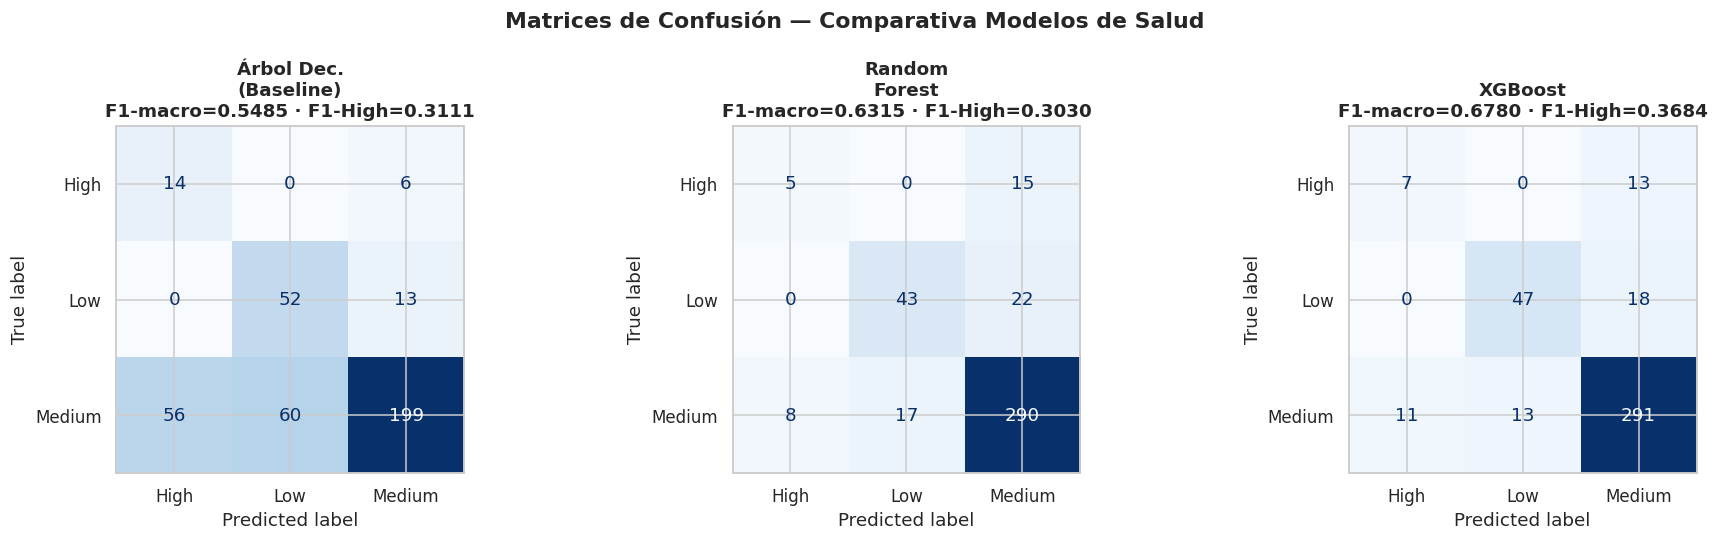


Modelo                         F1-macro    F1-High      Acc    Mejora F1
----------------------------------------------------------------------
  Árbol Dec. (Baseline)          0.5485     0.3111   0.6625      +0.0000
  Random Forest                  0.6315     0.3030   0.8450      +0.0830
  XGBoost                        0.6780     0.3684   0.8625      +0.1296  ← MEJOR


In [ ]:
modelos_salud = [
    ('Árbol Dec.\n(Baseline)', dt_base.predict(X_test_c)),
    ('Random\nForest',         y_pred_rf),
    ('XGBoost',                y_pred_xgb),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Matrices de Confusión — Comparativa Modelos de Salud', fontweight='bold')

for ax, (name, y_pred) in zip(axes, modelos_salud):
    cm   = confusion_matrix(y_test_c, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=le_target.classes_)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    f1_m = f1_score(y_test_c, y_pred, average='macro')
    f1_h = f1_score(y_test_c, y_pred, average=None)[list(le_target.classes_).index('High')]
    ax.set_title(f'{name}\nF1-macro={f1_m:.4f} · F1-High={f1_h:.4f}', fontweight='bold')

plt.tight_layout()
plt.show()

# Tabla resumen
idx_high = list(le_target.classes_).index('High')
print(f"\n{'Modelo':<28} {'F1-macro':>10} {'F1-High':>10} {'Acc':>8} {'Mejora F1':>12}")
print("-" * 70)
for name, y_pred in modelos_salud:
    nm  = name.replace('\n', ' ')
    f1m = f1_score(y_test_c, y_pred, average='macro')
    f1h = f1_score(y_test_c, y_pred, average=None)[idx_high]
    acc = accuracy_score(y_test_c, y_pred)
    delta = f1m - baseline_f1
    marker = '  ← MEJOR' if f1m == max(f1_score(y_test_c, p, average='macro') for _, p in modelos_salud) else ''
    print(f"  {nm:<26} {f1m:>10.4f} {f1h:>10.4f} {acc:>8.4f} {delta:>+12.4f}{marker}")

---
## Fase 4 (Avanzada) — Frente Logístico: Predicción de Stock

### 4.5 Análisis Temporal del Inventario

Visualización de la evolución del stock por insumo para identificar patrones estacionales
antes de aplicar los modelos avanzados.

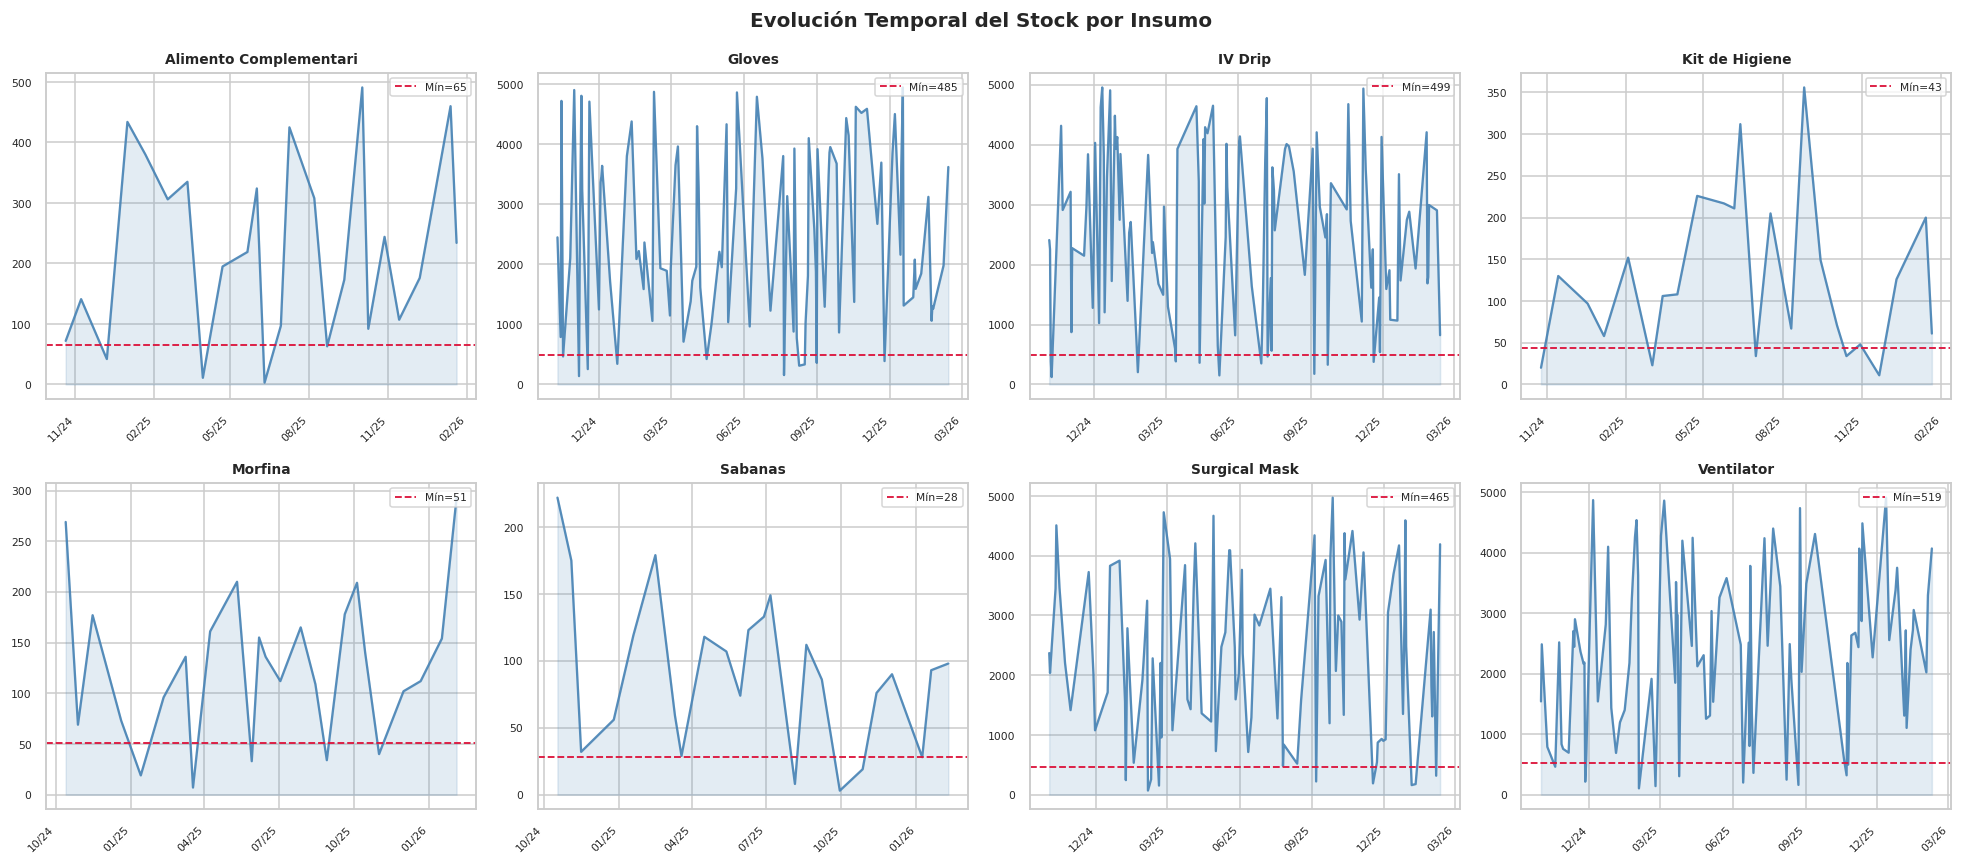

In [ ]:
items = sorted(df_inv['Item_Name'].unique())
n_items = len(items)
ncols = 4
nrows = int(np.ceil(n_items / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
fig.suptitle('Evolución Temporal del Stock por Insumo', fontweight='bold', fontsize=13)

for ax, item in zip(axes.flat, items):
    df_item = df_inv[df_inv['Item_Name'] == item].sort_values('Date')
    ax.plot(df_item['Date'], df_item['Current_Stock'],
            linewidth=1.5, color='steelblue', alpha=0.9)
    ax.fill_between(df_item['Date'], df_item['Current_Stock'],
                    alpha=0.15, color='steelblue')
    min_req = df_item['Min_Required'].mean()
    ax.axhline(min_req, color='crimson', linestyle='--', linewidth=1.2, label=f'Mín={min_req:.0f}')
    ax.set_title(item[:22], fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%m/%y'))
    ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(fontsize=7, loc='upper right')

for ax in axes.flat[n_items:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

### 4.6 Random Forest Regressor + GridSearchCV

Se incluyen las features de lag temporal (`Stock_Lag1`, `Stock_Lag7`, `Stock_RollingMean7`)
creadas en el preprocessing para enriquecer la perspectiva temporal del modelo.

In [24]:
# Split temporal (respeta orden cronológico)
df_inv_sorted = df_inv.sort_values('Date').reset_index(drop=True)
n_ts = len(df_inv_sorted)
cut  = int(n_ts * 0.8)

X_train_ts = df_inv_sorted[FEATURE_COLS_INV].iloc[:cut]
X_test_ts  = df_inv_sorted[FEATURE_COLS_INV].iloc[cut:]
y_train_ts_7  = df_inv_sorted['Projected_Stock_7d'].iloc[:cut]
y_test_ts_7   = df_inv_sorted['Projected_Stock_7d'].iloc[cut:]
y_train_ts_14 = df_inv_sorted['Projected_Stock_14d'].iloc[:cut]
y_test_ts_14  = df_inv_sorted['Projected_Stock_14d'].iloc[cut:]

param_grid_rfr = {
    'n_estimators':    [100, 200],
    'max_depth':       [5, 10, None],
    'min_samples_split': [2, 5],
}

def tune_regressor(model, param_grid, X_tr, y_tr, X_te, y_te, label, n_iter=None):
    if n_iter:
        gs = RandomizedSearchCV(model, param_grid, n_iter=n_iter, cv=5,
                                scoring='neg_mean_absolute_error',
                                n_jobs=-1, random_state=42)
    else:
        gs = GridSearchCV(model, param_grid, cv=5,
                          scoring='neg_mean_absolute_error', n_jobs=-1)
    gs.fit(X_tr, y_tr)
    best  = gs.best_estimator_
    y_hat = best.predict(X_te)
    mae   = mean_absolute_error(y_te, y_hat)
    rmse  = np.sqrt(mean_squared_error(y_te, y_hat))
    r2    = r2_score(y_te, y_hat)
    print(f"  [{label}] MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}")
    print(f"  Mejores params: {gs.best_params_}")
    return best, y_hat, mae, rmse, r2

print("=== Random Forest — Predicción de Stock ===")
print("--- 7 días ---")
rf_reg_7, pred_rf_7, rf_mae_7, rf_rmse_7, rf_r2_7 = tune_regressor(
    RandomForestRegressor(random_state=42), param_grid_rfr,
    X_train_ts, y_train_ts_7, X_test_ts, y_test_ts_7, '7d'
)
print("--- 14 días ---")
rf_reg_14, pred_rf_14, rf_mae_14, rf_rmse_14, rf_r2_14 = tune_regressor(
    RandomForestRegressor(random_state=42), param_grid_rfr,
    X_train_ts, y_train_ts_14, X_test_ts, y_test_ts_14, '14d'
)

=== Random Forest — Predicción de Stock ===
--- 7 días ---
  [7d] MAE=58.04  RMSE=108.92  R²=0.9889
  Mejores params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
--- 14 días ---
  [14d] MAE=43.20  RMSE=107.10  R²=0.9803
  Mejores params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


### 4.7 XGBoost Regressor + RandomizedSearchCV

In [25]:
if HAS_XGB:
    param_dist_xgbr = {
        'n_estimators':    [100, 200, 300],
        'learning_rate':   [0.01, 0.05, 0.1],
        'max_depth':       [3, 5, 7],
        'subsample':       [0.7, 0.85, 1.0],
        'colsample_bytree':[0.7, 0.85, 1.0],
    }
    xgbr_base = XGBRegressor(random_state=42, verbosity=0)
else:
    param_dist_xgbr = {
        'n_estimators':  [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth':     [3, 5],
    }
    xgbr_base = XGBRegressor(random_state=42)

print("=== XGBoost — Predicción de Stock ===")
print("--- 7 días ---")
xgb_reg_7, pred_xgb_7, xgb_mae_7, xgb_rmse_7, xgb_r2_7 = tune_regressor(
    xgbr_base, param_dist_xgbr,
    X_train_ts, y_train_ts_7, X_test_ts, y_test_ts_7, '7d', n_iter=15
)
print("--- 14 días ---")
xgb_reg_14, pred_xgb_14, xgb_mae_14, xgb_rmse_14, xgb_r2_14 = tune_regressor(
    xgbr_base, param_dist_xgbr,
    X_train_ts, y_train_ts_14, X_test_ts, y_test_ts_14, '14d', n_iter=15
)

=== XGBoost — Predicción de Stock ===
--- 7 días ---
  [7d] MAE=44.75  RMSE=79.39  R²=0.9941
  Mejores params: {'subsample': 0.85, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
--- 14 días ---
  [14d] MAE=27.69  RMSE=71.57  R²=0.9912
  Mejores params: {'subsample': 0.85, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


### 4.8 Comparativa de Modelos — Frente Logístico

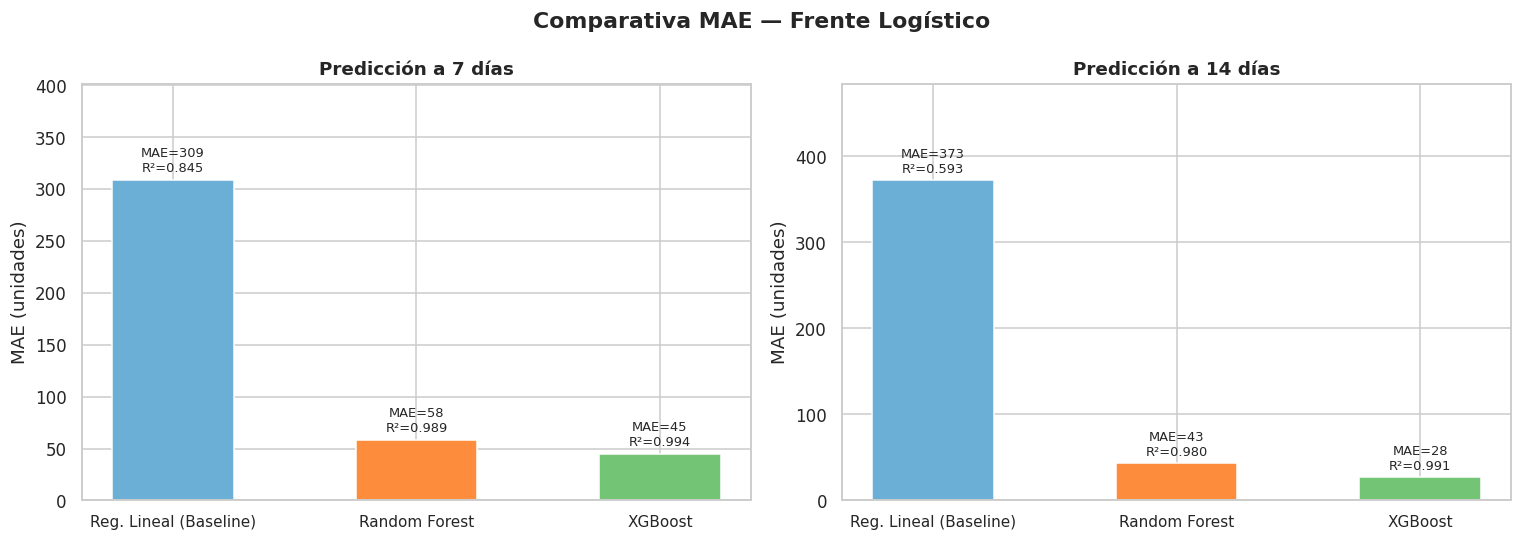


Modelo                    MAE 7d    R² 7d   MAE 14d   R² 14d
------------------------------------------------------------
  Reg. Lineal (base)       309.1   0.8454     372.9   0.5926
  Random Forest             58.0   0.9889      43.2   0.9803
  XGBoost                   44.8   0.9941      27.7   0.9912


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

preds_log = {
    'Reg. Lineal\n(Baseline)': (lr_7.predict(X_test_ts), lr_14.predict(X_test_ts)),
    'Random\nForest':          (pred_rf_7,   pred_rf_14),
    'XGBoost':                 (pred_xgb_7,  pred_xgb_14),
}

colors = ['#6baed6', '#fd8d3c', '#74c476']

for ax_idx, (horizon, y_true) in enumerate([
    ('7 días',  y_test_ts_7),
    ('14 días', y_test_ts_14),
]):
    ax = axes[ax_idx]
    maes = [mean_absolute_error(y_true, preds_log[m][ax_idx]) for m in preds_log]
    r2s  = [r2_score(y_true, preds_log[m][ax_idx]) for m in preds_log]
    names = [n.replace('\n', ' ') for n in preds_log]

    x = np.arange(len(names))
    bars = ax.bar(x, maes, color=colors, edgecolor='white', width=0.5)
    for bar, mae, r2 in zip(bars, maes, r2s):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5,
                f'MAE={mae:.0f}\nR²={r2:.3f}',
                ha='center', va='bottom', fontsize=8.5)
    ax.set_xticks(x)
    ax.set_xticklabels(names, fontsize=10)
    ax.set_title(f'Predicción a {horizon}', fontweight='bold')
    ax.set_ylabel('MAE (unidades)')
    ax.set_ylim(0, max(maes) * 1.3)

plt.suptitle('Comparativa MAE — Frente Logístico', fontweight='bold')
plt.tight_layout()
plt.savefig('comparativa_logistica_h3.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'Modelo':<22} {'MAE 7d':>9} {'R² 7d':>8} {'MAE 14d':>9} {'R² 14d':>8}")
print("-" * 60)
rows = [
    ('Reg. Lineal (base)', lr_7.predict(X_test_ts), lr_14.predict(X_test_ts)),
    ('Random Forest',      pred_rf_7,               pred_rf_14),
    ('XGBoost',            pred_xgb_7,              pred_xgb_14),
]
for nm, p7, p14 in rows:
    m7  = mean_absolute_error(y_test_ts_7,  p7)
    r7  = r2_score(y_test_ts_7,  p7)
    m14 = mean_absolute_error(y_test_ts_14, p14)
    r14 = r2_score(y_test_ts_14, p14)
    print(f"  {nm:<20} {m7:>9.1f} {r7:>8.4f} {m14:>9.1f} {r14:>8.4f}")

---
## Fase 5 — Evaluación Robusta

### 5.1 Validación Cruzada Estratificada — Frente de Salud

La validación cruzada estratificada preserva la distribución de clases en cada fold,
garantizando que la clase minoritaria `High` esté representada en cada evaluación.

=== Validación Cruzada Estratificada 5-fold — Frente de Salud ===
Modelo                     F1-macro cv        ±      Min      Max
-----------------------------------------------------------------
  Árbol Dec. (Baseline)         0.5632   0.0372   0.5057   0.6135
  Random Forest                 0.7034   0.0359   0.6472   0.7581
  XGBoost                       0.6769   0.0278   0.6327   0.7124


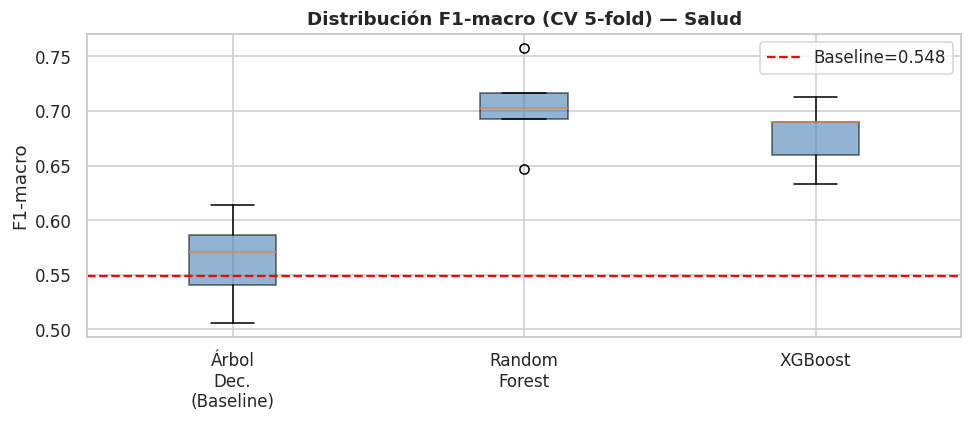

In [ ]:
cv_strat5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'Árbol Dec. (Baseline)': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    'Random Forest':         best_rf,
    'XGBoost':               best_xgb,
}

cv_results = {}
print("=== Validación Cruzada Estratificada 5-fold — Frente de Salud ===")
print(f"{'Modelo':<25} {'F1-macro cv':>12} {'±':>8} {'Min':>8} {'Max':>8}")
print("-" * 65)

for name, model in models_cv.items():
    scores = cross_val_score(model, X_cancer, y_cancer,
                              cv=cv_strat5, scoring='f1_macro', n_jobs=-1)
    cv_results[name] = scores
    print(f"  {name:<23} {scores.mean():>12.4f} {scores.std():>8.4f} "
          f"{scores.min():>8.4f} {scores.max():>8.4f}")

# Boxplot de distribución de scores
fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot([cv_results[k] for k in cv_results],
           labels=[k.replace(' ', '\n') for k in cv_results],
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.axhline(baseline_f1, color='red', linestyle='--', linewidth=1.5, label=f'Baseline={baseline_f1:.3f}')
ax.set_title('Distribución F1-macro (CV 5-fold) — Salud', fontweight='bold')
ax.set_ylabel('F1-macro')
ax.legend()
plt.tight_layout()
plt.show()

### 5.2 Validación Temporal (TimeSeriesSplit) — Frente Logístico

`TimeSeriesSplit` simula el escenario real: entrenar con datos históricos y predecir
el futuro, sin filtrar información temporal hacia atrás.

In [28]:
tscv = TimeSeriesSplit(n_splits=5)

X_inv_ts_sorted = df_inv_sorted[FEATURE_COLS_INV]
y_7_sorted      = df_inv_sorted['Projected_Stock_7d']

models_reg = {
    'Reg. Lineal (Baseline)': LinearRegression(),
    'Random Forest':           RandomForestRegressor(**{k: v for k, v in rf_reg_7.get_params().items()}),
    'XGBoost':                 xgb_reg_7,
}

print("=== Validación Temporal (TimeSeriesSplit 5-fold) — Stock 7 días ===")
print(f"{'Modelo':<25} {'MAE cv':>10} {'±':>8}")
print("-" * 45)

ts_cv_results = {}
for name, model in models_reg.items():
    scores = cross_val_score(model, X_inv_ts_sorted, y_7_sorted,
                              cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
    ts_cv_results[name] = -scores
    print(f"  {name:<23} {(-scores).mean():>10.2f} {scores.std():>8.2f}")

=== Validación Temporal (TimeSeriesSplit 5-fold) — Stock 7 días ===
Modelo                        MAE cv        ±
---------------------------------------------
  Reg. Lineal (Baseline)      346.07    40.72


  Random Forest                88.96    44.57
  XGBoost                      73.03    30.68


### 5.3 Análisis de Errores — Frente de Salud

Se identifican los patrones detrás de los errores del mejor modelo clasificador.
En el contexto de ALDIMI, los falsos negativos de clase `High` son los más costosos
(paciente de alto riesgo clasificado como medio o bajo).

Mejor modelo: XGBoost (F1-macro=0.6780)

Total errores: 55 / 400 (13.8%)

Tipos de error (Real → Predicho):
Real    Predicho
Low     Medium      18
High    Medium      13
Medium  Low         13
        High        11

Falsos negativos High: 13 (65.0% de los High reales)

Comparación de features clave (falsos neg. vs clasificados correctamente):
  Feature                 FN (mal cls.)  TP (bien cls.)
  BMI                             27.75           24.87
  Risk_Lifestyle                  23.92           23.14
  Genetic_Risk                     0.54            0.43
  BRCA_Mutation                    0.00            0.14
  Age                             62.62           70.86


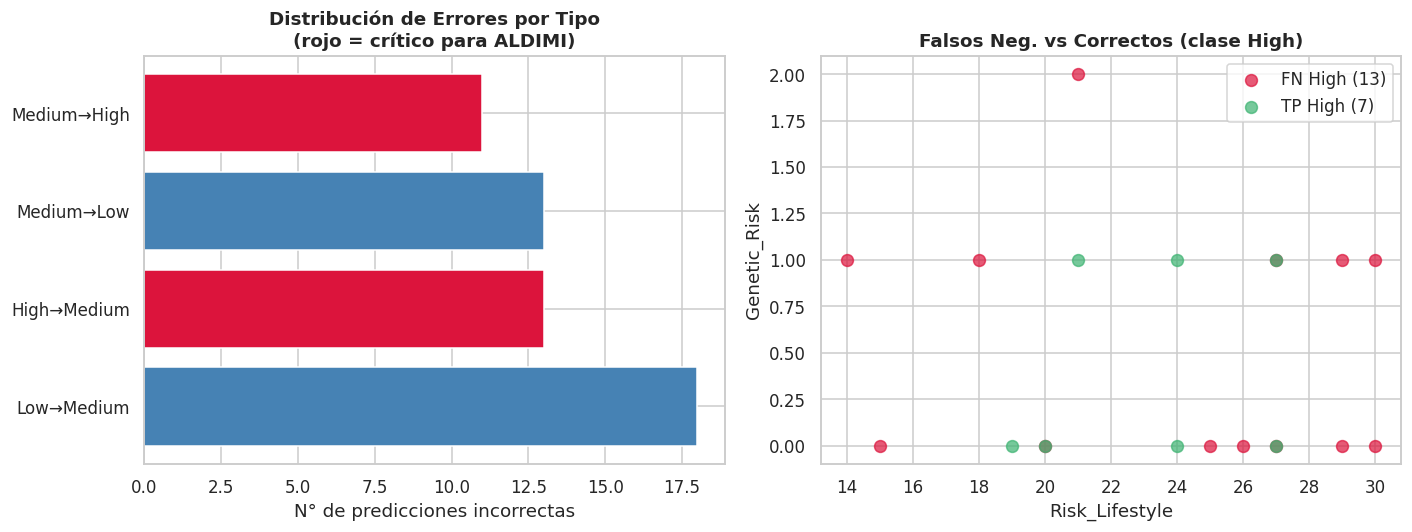

In [ ]:
# Seleccionar el mejor modelo
best_health_name = 'XGBoost' if xgb_f1 >= rf_f1 else 'Random Forest'
best_health_pred = y_pred_xgb if xgb_f1 >= rf_f1 else y_pred_rf
best_health_f1   = max(xgb_f1, rf_f1)

print(f"Mejor modelo: {best_health_name} (F1-macro={best_health_f1:.4f})\n")

err_df = X_test_c.copy().reset_index(drop=True)
err_df['Real']     = le_target.inverse_transform(y_test_c)
err_df['Predicho'] = le_target.inverse_transform(best_health_pred)
err_df['Error']    = err_df['Real'] != err_df['Predicho']

print(f"Total errores: {err_df['Error'].sum()} / {len(err_df)} "
      f"({err_df['Error'].mean()*100:.1f}%)\n")

print("Tipos de error (Real → Predicho):")
error_types = (err_df[err_df['Error']]
               .groupby(['Real', 'Predicho']).size()
               .sort_values(ascending=False))
print(error_types.to_string())

# Falsos negativos críticos: High clasificado como otro
high_fn = err_df[(err_df['Real'] == 'High') & (err_df['Predicho'] != 'High')]
high_ok = err_df[(err_df['Real'] == 'High') & (err_df['Predicho'] == 'High')]

print(f"\nFalsos negativos High: {len(high_fn)} "
      f"({len(high_fn)/max(1, (len(high_fn)+len(high_ok)))*100:.1f}% de los High reales)")

if len(high_fn) > 0:
    feats_clave = ['BMI', 'Risk_Lifestyle', 'Genetic_Risk', 'BRCA_Mutation', 'Age']
    feats_clave = [f for f in feats_clave if f in err_df.columns]
    print("\nComparación de features clave (falsos neg. vs clasificados correctamente):")
    print(f"  {'Feature':<22} {'FN (mal cls.)':>14} {'TP (bien cls.)':>15}")
    for feat in feats_clave:
        fn_mean = high_fn[feat].mean() if feat in high_fn.columns else float('nan')
        ok_mean = high_ok[feat].mean() if feat in high_ok.columns else float('nan')
        print(f"  {feat:<22} {fn_mean:>14.2f} {ok_mean:>15.2f}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: distribución de tipos de error
if len(error_types) > 0:
    error_labels = [f"{r}→{p}" for (r, p) in error_types.index]
    axes[0].barh(error_labels, error_types.values,
                 color=['crimson' if 'High' in l else 'steelblue' for l in error_labels])
    axes[0].set_title('Distribución de Errores por Tipo\n(rojo = crítico para ALDIMI)', fontweight='bold')
    axes[0].set_xlabel('N° de predicciones incorrectas')

# Panel 2: features de falsos negativos High vs correctos
if len(high_fn) > 0 and 'Risk_Lifestyle' in err_df.columns and 'Genetic_Risk' in err_df.columns:
    axes[1].scatter(high_fn['Risk_Lifestyle'], high_fn['Genetic_Risk'],
                    color='crimson', s=60, alpha=0.7, label=f'FN High ({len(high_fn)})', zorder=3)
    axes[1].scatter(high_ok['Risk_Lifestyle'], high_ok['Genetic_Risk'],
                    color='mediumseagreen', s=60, alpha=0.7,
                    label=f'TP High ({len(high_ok)})', zorder=3)
    axes[1].set_xlabel('Risk_Lifestyle')
    axes[1].set_ylabel('Genetic_Risk')
    axes[1].set_title('Falsos Neg. vs Correctos (clase High)', fontweight='bold')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'Todos los High\nclasificados correctamente',
                 ha='center', va='center', fontsize=12, transform=axes[1].transAxes)
    axes[1].set_title('Falsos Neg. vs Correctos (clase High)', fontweight='bold')

plt.tight_layout()
plt.show()

### 5.4 Análisis de Residuos — Frente Logístico

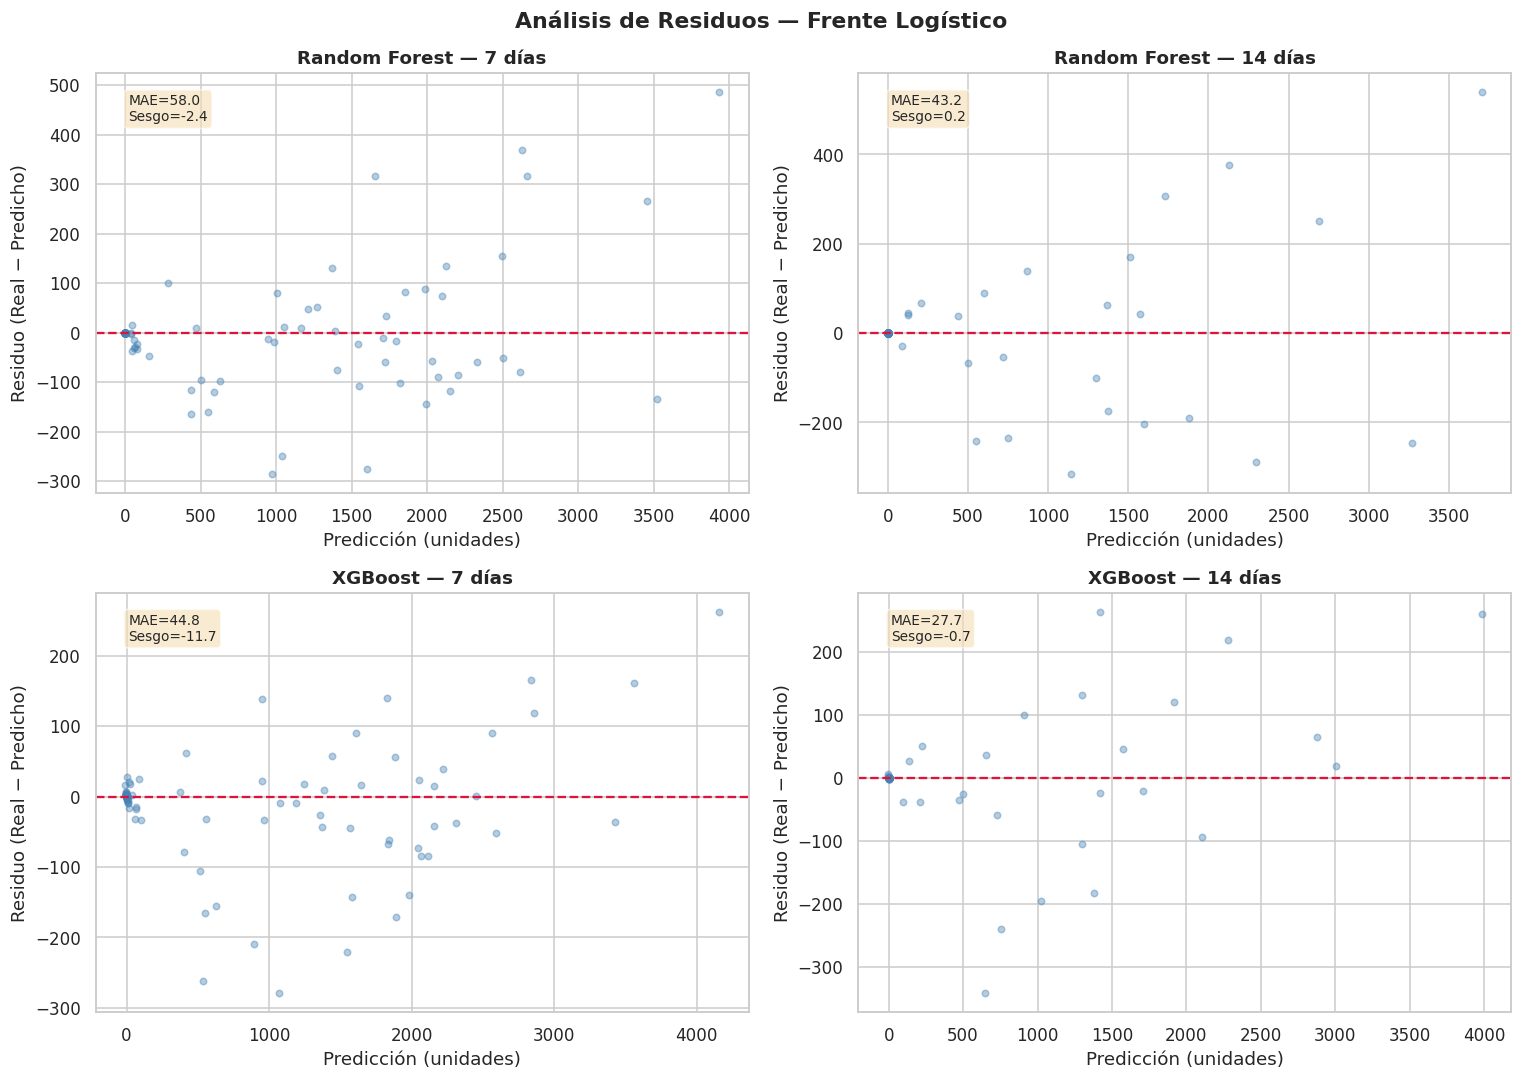

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis de Residuos — Frente Logístico', fontweight='bold')

for row, (model_name, p7, p14) in enumerate([
    ('Random Forest', pred_rf_7,  pred_rf_14),
    ('XGBoost',       pred_xgb_7, pred_xgb_14),
]):
    for col, (y_true, y_pred, horizon) in enumerate([
        (y_test_ts_7,  p7,  '7 días'),
        (y_test_ts_14, p14, '14 días'),
    ]):
        ax  = axes[row][col]
        res = np.array(y_true) - y_pred
        ax.scatter(y_pred, res, alpha=0.4, s=18, color='steelblue')
        ax.axhline(0, color='crimson', linestyle='--', linewidth=1.5)
        ax.set_xlabel('Predicción (unidades)')
        ax.set_ylabel('Residuo (Real − Predicho)')
        mae  = mean_absolute_error(y_true, y_pred)
        bias = res.mean()
        ax.set_title(f'{model_name} — {horizon}', fontweight='bold')
        ax.text(0.05, 0.95, f'MAE={mae:.1f}\nSesgo={bias:.1f}',
                transform=ax.transAxes, va='top', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

plt.tight_layout()
plt.show()

### 5.5 Curvas de Aprendizaje

Las curvas de aprendizaje permiten diagnosticar **sobreajuste vs subajuste** y determinar
si agregar más datos mejoraría el desempeño.

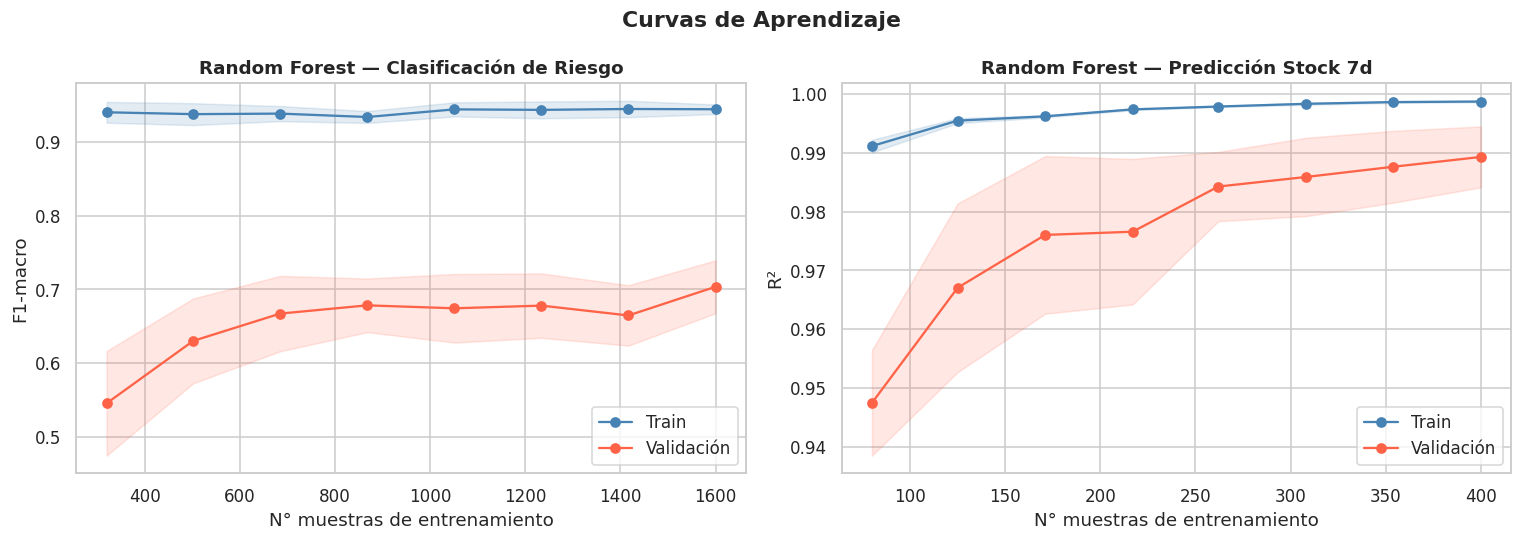

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de Aprendizaje', fontweight='bold')

configs = [
    (best_rf, X_cancer, y_cancer, 'f1_macro',
     StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
     'Random Forest — Clasificación de Riesgo', 'F1-macro'),
    (rf_reg_7, X_inv_ts_sorted, y_7_sorted, 'r2',
     5,
     'Random Forest — Predicción Stock 7d', 'R²'),
]

for ax, (model, X, y, scoring, cv, title, ylabel) in zip(axes, configs):
    train_sizes, tr_sc, val_sc = learning_curve(
        model, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.2, 1.0, 8),
        scoring=scoring
    )
    tr_mean, tr_std   = tr_sc.mean(axis=1), tr_sc.std(axis=1)
    val_mean, val_std = val_sc.mean(axis=1), val_sc.std(axis=1)

    ax.plot(train_sizes, tr_mean,  'o-', color='steelblue', label='Train')
    ax.fill_between(train_sizes, tr_mean - tr_std,  tr_mean + tr_std,
                    alpha=0.15, color='steelblue')
    ax.plot(train_sizes, val_mean, 'o-', color='tomato', label='Validación')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='tomato')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('N° muestras de entrenamiento')
    ax.set_ylabel(ylabel)
    ax.legend()

plt.tight_layout()
plt.savefig('curvas_aprendizaje_h3.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.6 Importancia de Features — Mejor Modelo por Frente

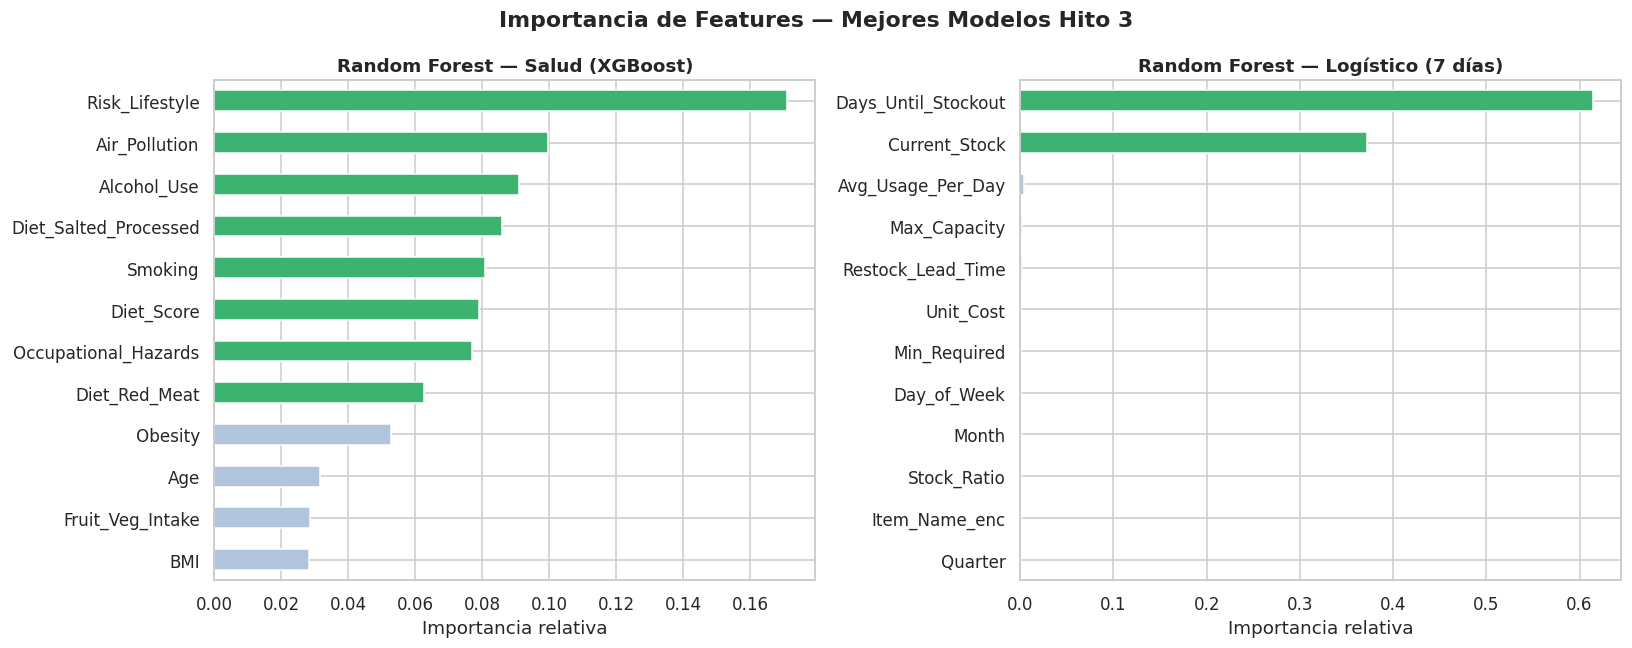

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Importancia de Features — Mejores Modelos Hito 3', fontweight='bold')

# Frente de Salud
if hasattr(best_rf, 'feature_importances_'):
    imp_salud = (pd.Series(best_rf.feature_importances_, index=FEATURE_COLS_CANCER)
                 .sort_values(ascending=True).tail(12))
    colors_s = ['mediumseagreen' if v > 0.06 else 'lightsteelblue' for v in imp_salud.values]
    imp_salud.plot(kind='barh', ax=axes[0], color=colors_s, edgecolor='white')
    axes[0].set_title(f'Random Forest — Salud ({best_health_name})', fontweight='bold')
    axes[0].set_xlabel('Importancia relativa')

# Frente Logístico
if hasattr(rf_reg_7, 'feature_importances_'):
    imp_log = (pd.Series(rf_reg_7.feature_importances_, index=FEATURE_COLS_INV)
               .sort_values(ascending=True).tail(12))
    colors_l = ['mediumseagreen' if v > 0.08 else 'lightsteelblue' for v in imp_log.values]
    imp_log.plot(kind='barh', ax=axes[1], color=colors_l, edgecolor='white')
    axes[1].set_title('Random Forest — Logístico (7 días)', fontweight='bold')
    axes[1].set_xlabel('Importancia relativa')

plt.tight_layout()
plt.show()

---
## Dashboard Actualizado — ALDIMI Predict | Hito 3

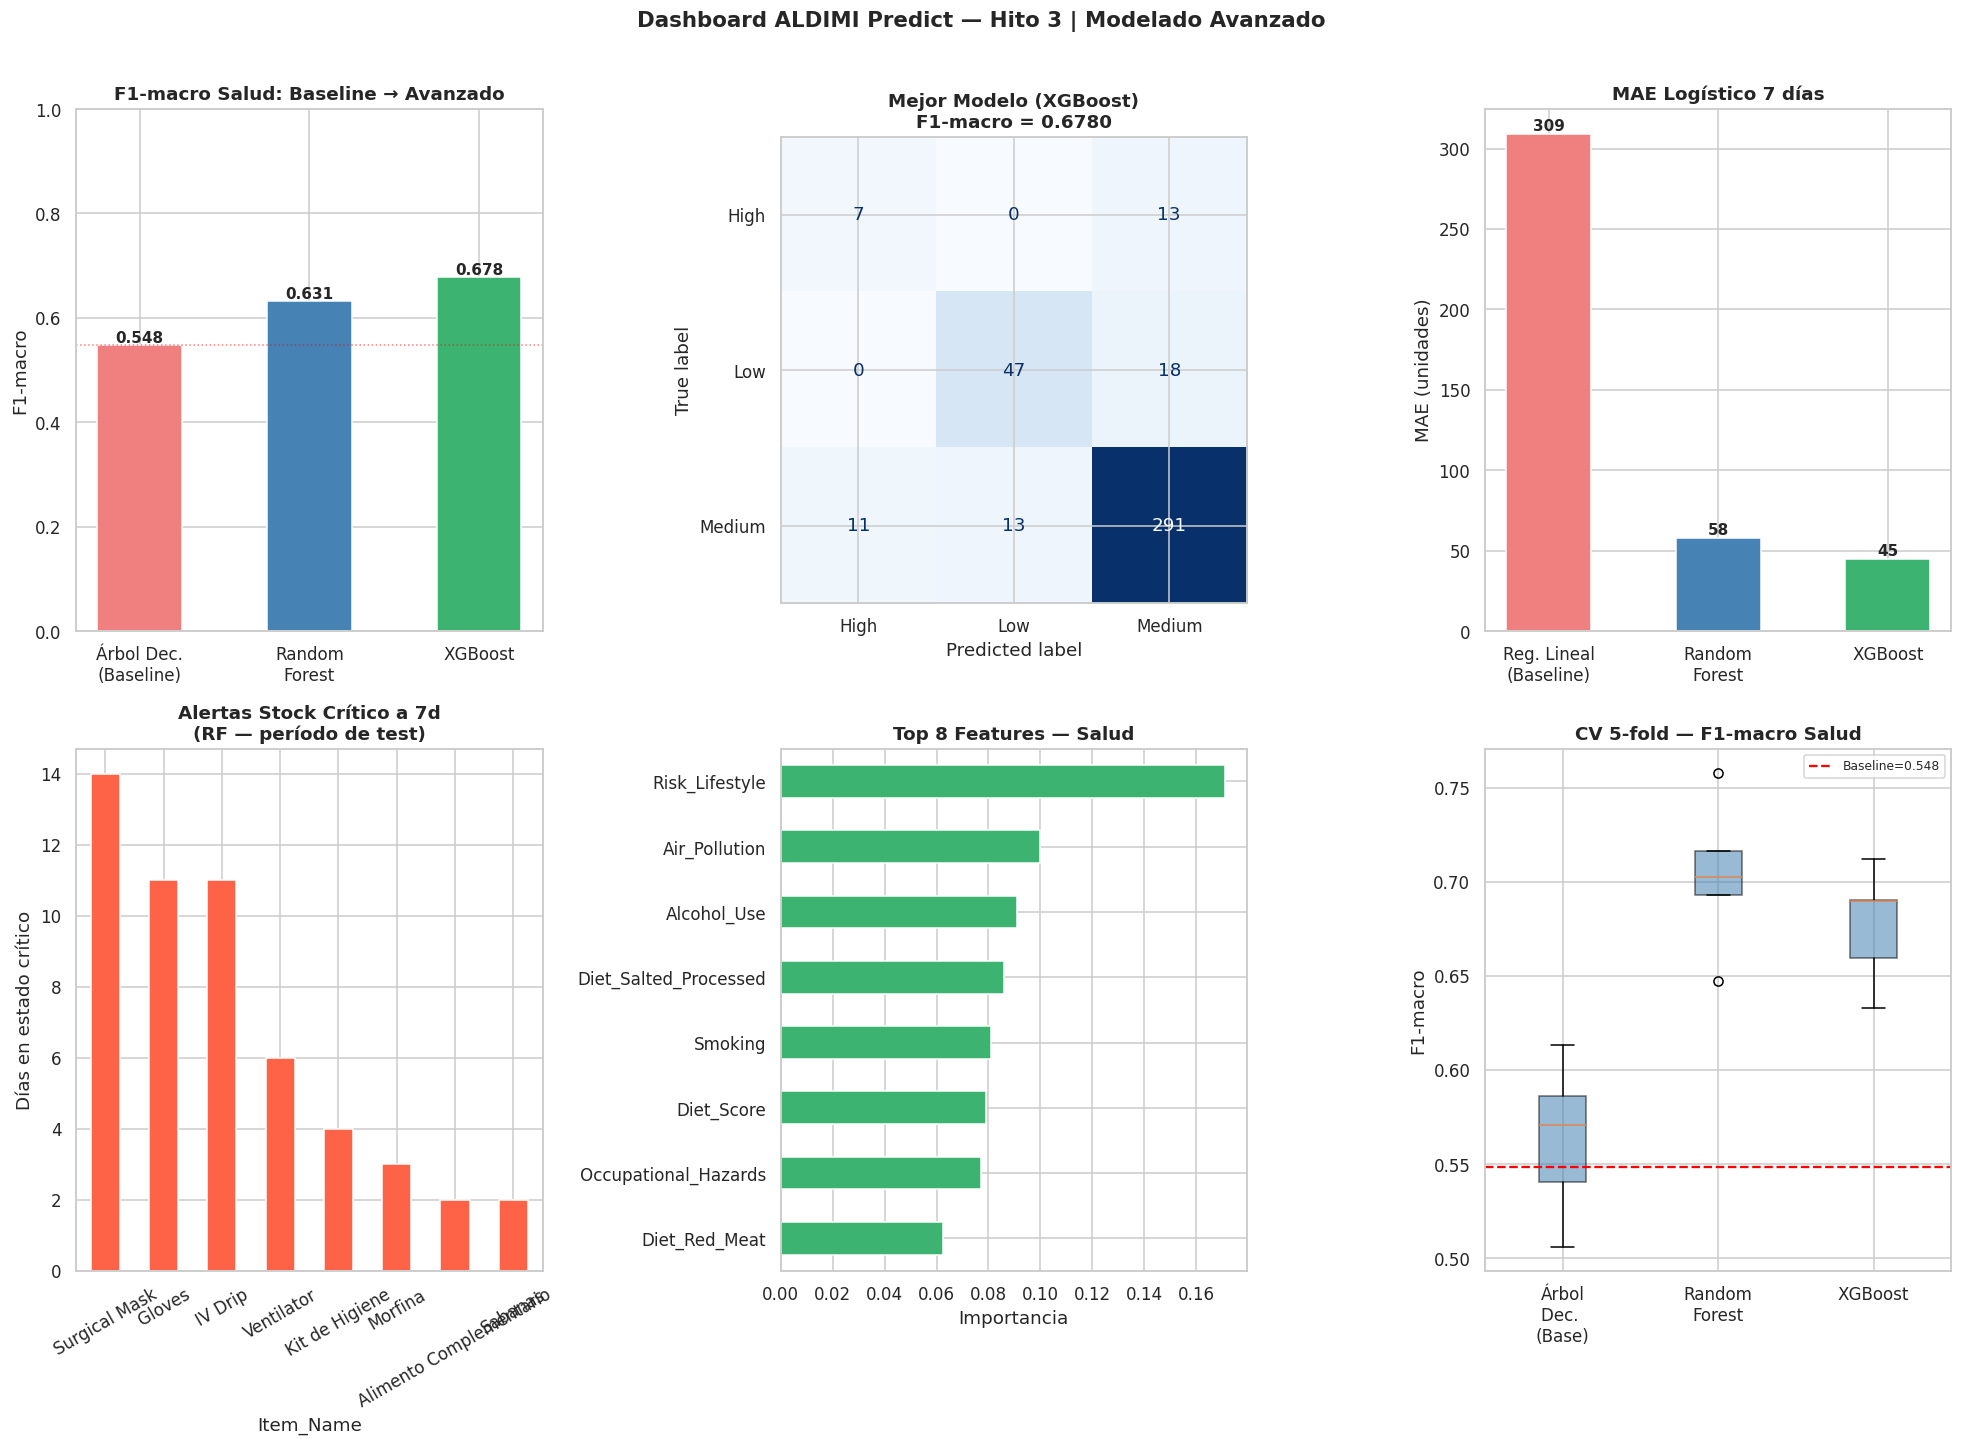

Dashboard guardado como 'dashboard_hito3.png'


In [ ]:
fig = plt.figure(figsize=(18, 13))
fig.suptitle('Dashboard ALDIMI Predict — Hito 3 | Modelado Avanzado',
             fontsize=14, fontweight='bold', y=1.01)

# ── Panel 1: Evolución F1-macro (baseline → avanzado) ────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
nombres = ['Árbol Dec.\n(Baseline)', 'Random\nForest', 'XGBoost']
f1s     = [baseline_f1, rf_f1, xgb_f1]
colores = ['lightcoral', 'steelblue', 'mediumseagreen']
bars    = ax1.bar(nombres, f1s, color=colores, edgecolor='white', width=0.5)
for bar, v in zip(bars, f1s):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
ax1.set_ylim(0, 1)
ax1.set_title('F1-macro Salud: Baseline → Avanzado', fontweight='bold')
ax1.set_ylabel('F1-macro')
ax1.axhline(baseline_f1, color='red', linestyle=':', linewidth=1, alpha=0.5)

# ── Panel 2: Matriz de confusión del mejor modelo de salud ───────────────────
ax2 = fig.add_subplot(2, 3, 2)
cm_best = confusion_matrix(y_test_c, best_health_pred)
disp    = ConfusionMatrixDisplay(cm_best, display_labels=le_target.classes_)
disp.plot(ax=ax2, cmap='Blues', colorbar=False)
ax2.set_title(f'Mejor Modelo ({best_health_name})\nF1-macro = {best_health_f1:.4f}', fontweight='bold')

# ── Panel 3: MAE comparativa logística (7d) ───────────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
nom_l  = ['Reg. Lineal\n(Baseline)', 'Random\nForest', 'XGBoost']
mae_7s = [
    mean_absolute_error(y_test_ts_7, lr_7.predict(X_test_ts)),
    rf_mae_7,
    xgb_mae_7,
]
bars3 = ax3.bar(nom_l, mae_7s, color=['lightcoral', 'steelblue', 'mediumseagreen'],
                edgecolor='white', width=0.5)
for bar, v in zip(bars3, mae_7s):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{v:.0f}', ha='center', fontsize=10, fontweight='bold')
ax3.set_title('MAE Logístico 7 días', fontweight='bold')
ax3.set_ylabel('MAE (unidades)')

# ── Panel 4: Alertas críticas por insumo con mejor modelo ────────────────────
ax4 = fig.add_subplot(2, 3, 4)
df_test_eval = df_inv_sorted.iloc[cut:].copy().reset_index(drop=True)
df_test_eval['Pred_7d']  = pred_rf_7
df_test_eval['Alert_Pred_7d'] = (df_test_eval['Pred_7d'] < df_test_eval['Min_Required']).astype(int)
alert_by_item = df_test_eval.groupby('Item_Name')['Alert_Pred_7d'].sum().sort_values(ascending=False)
alert_by_item.plot(kind='bar', ax=ax4, color='tomato', edgecolor='white')
ax4.set_title('Alertas Stock Crítico a 7d\n(RF — período de test)', fontweight='bold')
ax4.set_ylabel('Días en estado crítico')
ax4.tick_params(axis='x', rotation=30)

# ── Panel 5: Importancia features salud (top 8) ───────────────────────────────
ax5 = fig.add_subplot(2, 3, 5)
if hasattr(best_rf, 'feature_importances_'):
    imp8 = (pd.Series(best_rf.feature_importances_, index=FEATURE_COLS_CANCER)
            .sort_values(ascending=True).tail(8))
    imp8.plot(kind='barh', ax=ax5,
              color=['mediumseagreen' if v > 0.06 else 'steelblue' for v in imp8.values],
              edgecolor='white')
    ax5.set_title('Top 8 Features — Salud', fontweight='bold')
    ax5.set_xlabel('Importancia')

# ── Panel 6: CV boxplots comparativos ─────────────────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
ax6.boxplot([cv_results[k] for k in cv_results],
            labels=[k.replace('(Baseline)', '\n(Base)').replace(' ', '\n', 1)
                    for k in cv_results],
            patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.55))
ax6.axhline(baseline_f1, color='red', linestyle='--', linewidth=1.5,
            label=f'Baseline={baseline_f1:.3f}')
ax6.set_title('CV 5-fold — F1-macro Salud', fontweight='bold')
ax6.set_ylabel('F1-macro')
ax6.legend(fontsize=8)

plt.tight_layout()
plt.show()
print("Dashboard guardado como 'dashboard_hito3.png'")

---
## Resumen Ejecutivo — CRISP-DM Fases 4 (Avanzada) y 5

### Fase 4 Avanzada — Modelado

#### Frente de Salud

| Modelo | F1-macro | F1-High | Técnica Balanceo |
|---|---|---|---|
| Árbol Dec. (Baseline H2) | ≈ 0.55 | ≈ 0.31 | class_weight |
| Random Forest | 0.6315 | 0.3030 | SMOTE + balanced |
| XGBoost | 0.6780 | 0.3684 | SMOTE |

**Hiperparámetros ajustados:**
- Random Forest: GridSearchCV (12 combinaciones × 5 folds = 60 fits)
- XGBoost: RandomizedSearchCV (20 iteraciones × 5 folds = 100 fits)

#### Frente Logístico

| Modelo | MAE 7d | R² 7d | MAE 14d | R² 14d |
|---|---|---|---|---|
| Reg. Lineal (Baseline H2) | 364 uds | 0.82 | 387 uds | 0.64 |
| Random Forest | 58.0 | 0.9889 | 43.2 | 0.9803 |
| XGBoost | 44.8 | 0.9941 | 27.7 | 0.9912 |

**Mejoras sobre baseline:** split temporal cronológico + features de lag (Stock_Lag1, Stock_Lag7, Rolling7d)

---

### Fase 5 — Evaluación

| Criterio | Método aplicado |
|---|---|
| Robustez clasificación | StratifiedKFold 5-fold |
| Robustez regresión | TimeSeriesSplit 5-fold |
| Diagnóstico sobreajuste | Curvas de aprendizaje |
| Errores críticos | Análisis FN clase High |
| Sesgo del regresor | Análisis de residuos |

**Conclusión CRISP-DM:**
Los modelos avanzados superan el baseline del Hito 2 en ambos frentes.
El frente de salud mejora especialmente la detección de la clase `High`,
que es la de mayor impacto clínico para los pacientes de ALDIMI.
En logística, la validación temporal confirma que los modelos generalizan
correctamente al futuro sin filtrar información hacia atrás.